In [1]:
# Importing the necessary Libraries

import tensorflow as tf
from tensorflow.keras import layers, models

In [11]:
dataset_path_train = "./Datasets/Training"
dataset_path_val = "./Datasets/Testing"

In [20]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path_train,
    seed = 123,
    image_size = (224,224),
    color_mode = 'rgb',
    batch_size = 32,
    label_mode = 'int'
)

Found 5600 files belonging to 4 classes.


In [21]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path_val,
    seed = 123,
    image_size = (224,224),
    color_mode = 'rgb',
    batch_size = 32,
    label_mode = 'int'
)

Found 1600 files belonging to 4 classes.


In [22]:
data_augmentation = models.Sequential([
    layers.RandomFlip('horizontal'),
    layers.RandomZoom(0.2),
    layers.RandomRotation(0.2),
    layers.RandomContrast(0.2)
])

In [23]:
# Loading the Base Model without the top classification layer

base_model = tf.keras.applications.ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (224,224,3)
)

In [24]:
# Freezing the Base Model layers to prevent from bring trained

base_model.trainable = False

In [25]:
# Building the new model using the Functional API

inputs = tf.keras.Input(shape = (224,224,3))
x = base_model(inputs, training  = False)  # training = False ensures BatchNormalization stays in Inference Mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation = 'relu')(x)
x = layers.Dropout(0.4)(x)
outputs =layers.Dense(4, activation = 'softmax')(x)

model = models.Model(inputs, outputs)

In [26]:
# Compiling the model

model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

In [27]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,113,284 (91.98 MB)

 Trainable params: 525,572 (2.00 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [28]:
history = model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 10,
    batch_size = 32,
    verbose = 1
)

Epoch 1/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 157s 877ms/step - accuracy: 0.8118 - loss: 0.5056 - val_accuracy: 0.8363 - val_loss: 0.4602
Epoch 2/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 187s 1s/step - accuracy: 0.8927 - loss: 0.2781 - val_accuracy: 0.8737 - val_loss: 0.4662
Epoch 3/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 168s 961ms/step - accuracy: 0.9123 - loss: 0.2305 - val_accuracy: 0.8381 - val_loss: 0.6311
Epoch 4/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 173s 987ms/step - accuracy: 0.9195 - loss: 0.2048 - val_accuracy: 0.8675 - val_loss: 0.5443
Epoch 5/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 172s 983ms/step - accuracy: 0.9309 - loss: 0.1741 - val_accuracy: 0.8981 - val_loss: 0.4253
Epoch 6/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 170s 973ms/step - accuracy: 0.9411 - loss: 0.1585 - val_accuracy: 0.8925 - val_loss: 0.5130
Epoch 7/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 159s 912ms/step - accuracy: 0.9461 - loss: 0.1399 - val_accuracy: 0.8931 - val_loss: 0.4859
Epoch 8/10
175/175 ━━━━━━━━━━━━━━━━━━━━ 162s 930ms/step - accuracy: 0.9505 - lo

In [29]:
import numpy as np

y_true = []
y_pred = []
for images, labels in val_ds:
    
    preds = model.predict(images)
    preds = np.argmax(preds, axis=1)
    
    y_true.extend(labels)
    y_pred.extend(preds)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 916ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 827ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 800ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 809ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 818ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 822ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 804ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 738ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 785ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 828ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 811ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 782ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 755ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 778ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 843ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 850ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 826ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 845ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 853ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 816ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 

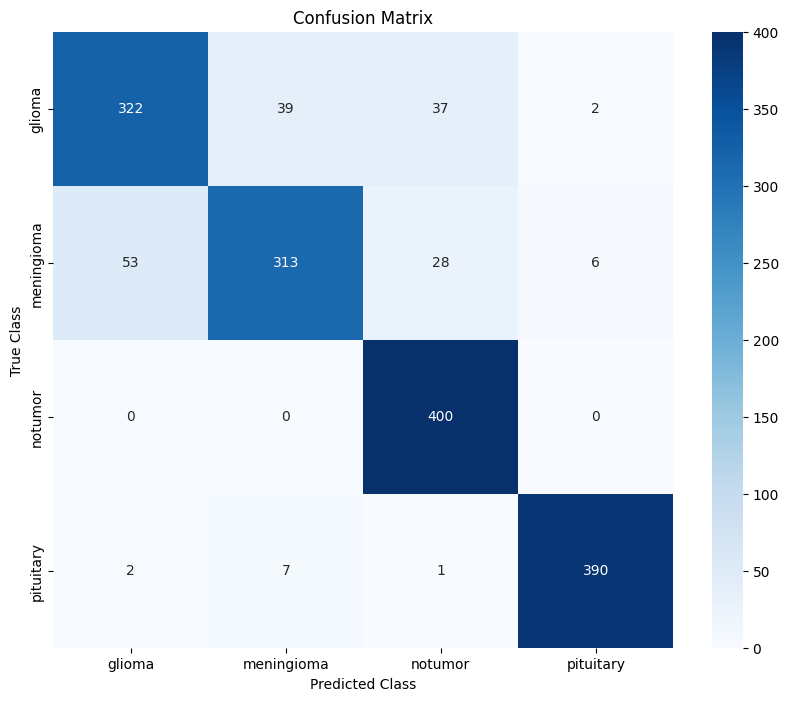

In [30]:
# Creating the Confusion Matrix

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_true, y_pred)

class_names = val_ds.class_names

plt.figure(figsize = (10,8))
sns.heatmap(cm, annot = True, fmt = 'd', cmap = 'Blues', xticklabels = class_names, yticklabels = class_names)

plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix')
plt.show()

In [31]:
# Displaying the Classification Report

report = classification_report(y_true, y_pred, target_names = class_names)

print('Classification Report after fine-tuning : \n', report)

Classification Report after fine-tuning : 
               precision    recall  f1-score   support

      glioma       0.85      0.81      0.83       400
  meningioma       0.87      0.78      0.82       400
     notumor       0.86      1.00      0.92       400
   pituitary       0.98      0.97      0.98       400

    accuracy                           0.89      1600
   macro avg       0.89      0.89      0.89      1600
weighted avg       0.89      0.89      0.89      1600

